# 05 — Evaluation: Comparing All Three Pipelines

This notebook loads the generated data from all three pipelines and compares them:

1. **FM-Gene Space** (2000d direct)
2. **FM-PCA Space** (20d PCA latent)
3. **FM-AE Latent** (20d autoencoder latent)

**Metrics:**
- Gene-wise mean and std MSE (how well per-gene statistics are preserved)
- MMD — Maximum Mean Discrepancy (distributional similarity)
- UMAP visualization (qualitative overlap)
- Marker gene correlation heatmaps
- Memorization check (are generated samples novel?)

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config as cfg
from src.preprocess import set_seed, load_processed
from src.metrics import (
    distribution_metrics, compute_mmd, memorization_check,
    plot_umap_overlay, plot_marker_correlation,
)

set_seed()
print(f"Device: {cfg.DEVICE}")

Device: cuda


## 1. Load All Data

In [2]:
data = load_processed()
X_real = data["X_all"]
X_train_s = data["X_train_s"]
scaler = data["scaler"]
hvg_names = data["hvg_names"]

# Load generated data from each pipeline
X_gen_pca = np.load(os.path.join(cfg.DATA_DIR, "X_gen_pca.npy"))
X_gen_ae = np.load(os.path.join(cfg.DATA_DIR, "X_gen_ae.npy"))
X_gen_gene = np.load(os.path.join(cfg.DATA_DIR, "X_gen_gene.npy"))

print(f"Real:     {X_real.shape}")
print(f"FM-Gene:  {X_gen_gene.shape}")
print(f"FM-PCA:   {X_gen_pca.shape}")
print(f"FM-AE:    {X_gen_ae.shape}")

Real:     (2638, 2000)
FM-Gene:  (2638, 2000)
FM-PCA:   (2638, 2000)
FM-AE:    (2638, 2000)


## 2. Gene-wise Distribution Comparison

In [3]:
# Quantitative metrics
results = []
for name, X_gen in [("FM-Gene", X_gen_gene), ("FM-PCA", X_gen_pca), ("FM-AE", X_gen_ae)]:
    m = distribution_metrics(X_real, X_gen)
    m["Method"] = name
    results.append(m)

df_dist = pd.DataFrame(results)[["Method", "Mean MSE", "Std MSE"]]
print(df_dist.to_string(index=False))

 Method  Mean MSE  Std MSE
FM-Gene  0.000514 0.003710
 FM-PCA  0.000073 0.130156
  FM-AE  0.000105 0.128824


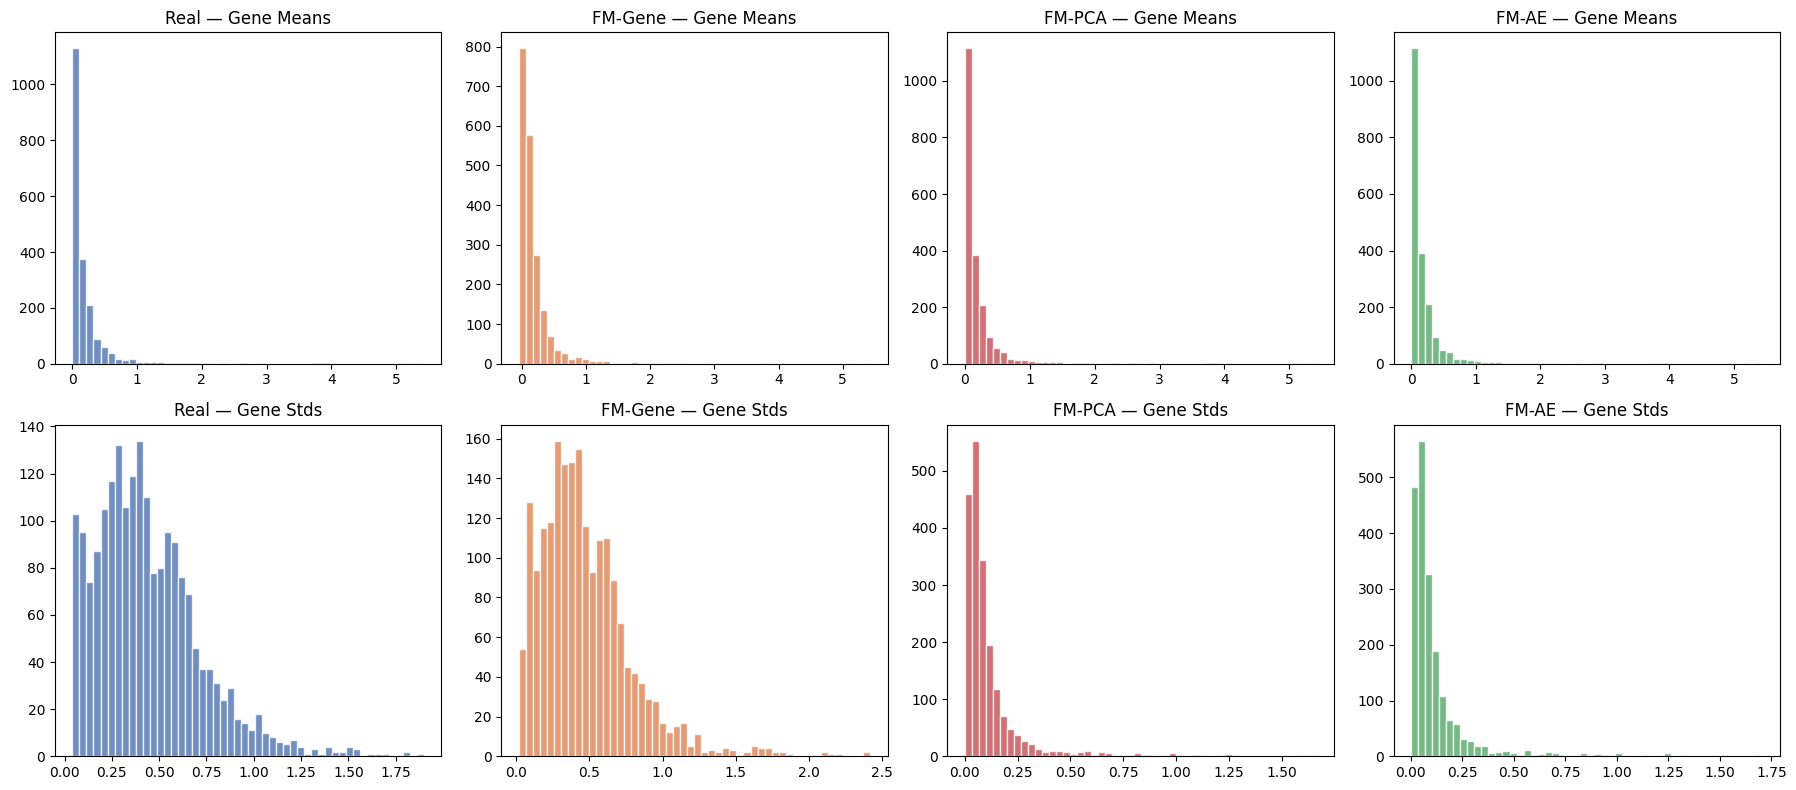

In [4]:
# Visual comparison: gene mean and std distributions
labels = ["Real", "FM-Gene", "FM-PCA", "FM-AE"]
datasets = [X_real, X_gen_gene, X_gen_pca, X_gen_ae]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, (label, dat, color) in enumerate(zip(labels, datasets, colors)):
    gene_means = dat.mean(axis=0)
    gene_stds = dat.std(axis=0)
    axes[0, col].hist(gene_means, bins=50, color=color, alpha=0.8, edgecolor="white")
    axes[0, col].set_title(f"{label} — Gene Means")
    axes[1, col].hist(gene_stds, bins=50, color=color, alpha=0.8, edgecolor="white")
    axes[1, col].set_title(f"{label} — Gene Stds")
plt.tight_layout()
plt.show()

## 3. MMD (Maximum Mean Discrepancy)

In [5]:
print("Computing MMD (this may take a minute)...")

# Baseline: real vs real (split in half)
n_half = len(X_real) // 2
mmd_baseline = compute_mmd(X_real[:n_half], X_real[n_half:])
mmd_gene = compute_mmd(X_real, X_gen_gene)
mmd_pca = compute_mmd(X_real, X_gen_pca)
mmd_ae = compute_mmd(X_real, X_gen_ae)

df_mmd = pd.DataFrame([
    {"Method": "Real vs Real (baseline)", "MMD": mmd_baseline},
    {"Method": "FM-Gene", "MMD": mmd_gene},
    {"Method": "FM-PCA", "MMD": mmd_pca},
    {"Method": "FM-AE", "MMD": mmd_ae},
])
print(df_mmd.to_string(index=False))

Computing MMD (this may take a minute)...
                 Method      MMD
Real vs Real (baseline) 0.008622
                FM-Gene 0.035222
                 FM-PCA 0.274598
                  FM-AE 0.273488


## 4. UMAP Visualization

/home/zhuoyuan/miniconda3/envs/GenAI_single_cell/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


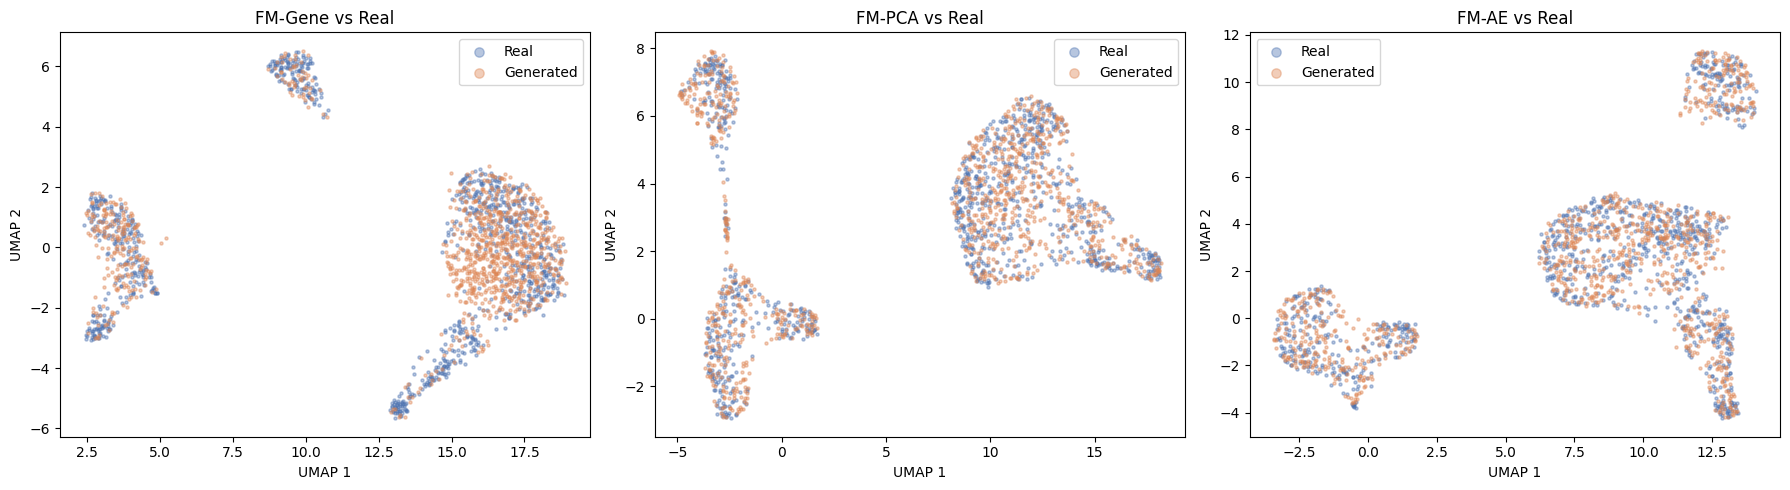

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (X_gen, title) in zip(axes, [
    (X_gen_gene, "FM-Gene vs Real"),
    (X_gen_pca, "FM-PCA vs Real"),
    (X_gen_ae, "FM-AE vs Real"),
]):
    plot_umap_overlay(X_real, X_gen, title=title, ax=ax)
plt.tight_layout()
plt.show()

## 5. Marker Gene Correlation

/home/zhuoyuan/CSprojects/GenAI_SingleCell/src/metrics.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


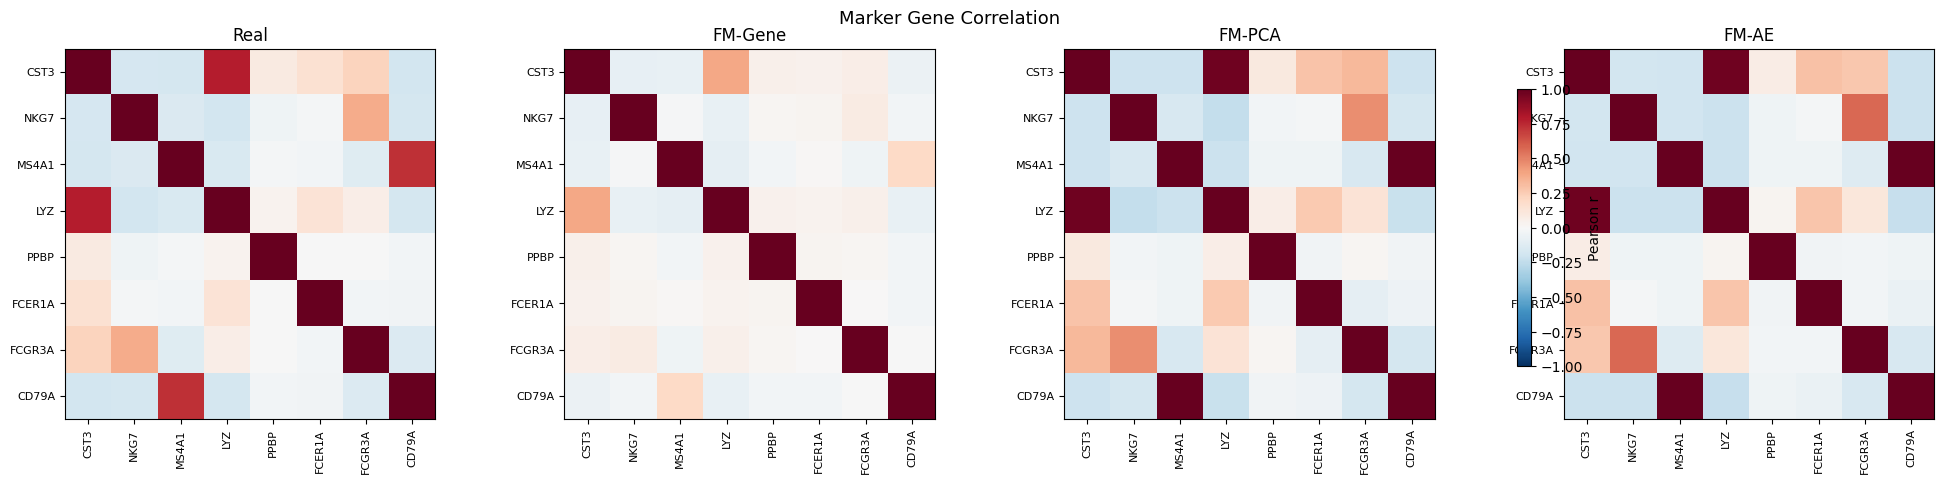

In [7]:
fig = plot_marker_correlation(
    {"Real": X_real, "FM-Gene": X_gen_gene, "FM-PCA": X_gen_pca, "FM-AE": X_gen_ae},
    hvg_names=hvg_names,
)
plt.show()

## 6. Memorization Check

We verify that generated samples are novel by comparing nearest-neighbor distances.
If the model memorized training data, generated→training NN distances would be
much smaller than training→training NN distances.

In [8]:
# Use standardized data for distance comparison
X_train_orig = data["X_train_s"]

mem_results = []
for name, X_gen in [("FM-Gene", X_gen_gene), ("FM-PCA", X_gen_pca), ("FM-AE", X_gen_ae)]:
    X_gen_s = data["scaler"].transform(X_gen)
    mc = memorization_check(X_gen_s, X_train_orig)
    mc["Method"] = name
    mem_results.append(mc)

df_mem = pd.DataFrame(mem_results)[[
    "Method", "gen_to_train_nn_mean", "train_to_train_nn_mean", "ratio_mean"
]]
df_mem.columns = ["Method", "Gen→Train NN (mean)", "Train→Train NN (mean)", "Ratio"]
print(df_mem.to_string(index=False))
print("\nRatio ~ 1.0 means generated samples are as distant from training as training samples are from each other (good).")
print("Ratio << 1.0 would indicate memorization (generated samples too close to training data).")

 Method  Gen→Train NN (mean)  Train→Train NN (mean)    Ratio
FM-Gene            55.421635              53.121208 1.043305
 FM-PCA            32.201729              53.121208 0.606193
  FM-AE            32.493801              53.121208 0.611692

Ratio ~ 1.0 means generated samples are as distant from training as training samples are from each other (good).
Ratio << 1.0 would indicate memorization (generated samples too close to training data).


## 7. Summary

In [9]:
# Combine all metrics
summary = df_dist.copy()
summary["MMD"] = [mmd_gene, mmd_pca, mmd_ae]
summary["Memorization Ratio"] = [r["ratio_mean"] for r in mem_results]

print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(summary.to_string(index=False, float_format="{:.6f}".format))
print(f"\nBaseline MMD (Real vs Real): {mmd_baseline:.6f}")
print("=" * 70)

FINAL RESULTS SUMMARY
 Method  Mean MSE  Std MSE      MMD  Memorization Ratio
FM-Gene  0.000514 0.003710 0.035222            1.043305
 FM-PCA  0.000073 0.130156 0.274598            0.606193
  FM-AE  0.000105 0.128824 0.273488            0.611692

Baseline MMD (Real vs Real): 0.008622
